#### Install and Import all required libraries

In [21]:
# Mount Google Drive and import all libraries
import os
import sys
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set, MessagePassing
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from torch_geometric.utils import scatter
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure, Element
from torch.utils.data import Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

!pip install pysr
from pysr import PySRRegressor

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility (critical for scientific research)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = "/content/drive/MyDrive/IML Project"

DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
CIF_DIR = os.path.join(BASE_DIR)

GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


 Load Data

In [22]:
df = pd.read_csv(DATA_PATH)
df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [23]:
print("Total samples:", len(df))

Total samples: 9668


Prepare Tabular Data

In [24]:
# Check class balance
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64


In [25]:
# Build absolute CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(CIF_DIR, x))

# Quick check
print(df[['cif', 'cif_path']].head())

                   cif                                           cif_path
0   cifs/mp-573069.cif  /content/drive/MyDrive/IML Project/cifs/mp-573...
1  cifs/mp-1193609.cif  /content/drive/MyDrive/IML Project/cifs/mp-119...
2    cifs/mp-21420.cif  /content/drive/MyDrive/IML Project/cifs/mp-214...
3     cifs/mp-4920.cif  /content/drive/MyDrive/IML Project/cifs/mp-492...
4    cifs/mp-15827.cif  /content/drive/MyDrive/IML Project/cifs/mp-158...


# Train / Val / Test Split (STRATIFIED)

In [26]:
# SPLIT DATA
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6767 | Val: 1450 | Test: 1451


#   Prepare graphical data

# Feature Extraction

In [27]:
# FEATURE EXTRACTION
def get_atom_features(element):
    el = Element(element)

    return [
        el.Z,
        el.X if el.X else 0,
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0
    ]


def extract_global_features(row, structure):
    return [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

# Collect TRAIN Features (for scaling ONLY)

In [28]:
# COLLECT TRAIN FEATURES
node_samples = []
edge_samples = []
global_samples = []

cutoff = 6.0

for _, row in train_df.iterrows():
    try:
        structure = Structure.from_file(row['cif_path'])

        # Node features
        for site in structure:
            node_samples.append(get_atom_features(site.specie.symbol))

        # Edge features (distance)
        for i, site in enumerate(structure):
            neighbors = structure.get_neighbors(site, cutoff)
            for n in neighbors:
                edge_samples.append([n.nn_distance])

        # Global features
        global_samples.append(extract_global_features(row, structure))

    except Exception as e:
        print(f"Error processing {row['cif_path']} | {e}")

# Convert safely
node_samples = np.array(node_samples)
edge_samples = np.array(edge_samples)
global_samples = np.array(global_samples)

print("Node shape:", node_samples.shape)
print("Edge shape:", edge_samples.shape)
print("Global shape:", global_samples.shape)

Node shape: (211448, 5)
Edge shape: (11843614, 1)
Global shape: (6767, 14)


# Fit Scalers (TRAIN ONLY)

In [29]:
# SCALING

node_scaler = StandardScaler().fit(node_samples)
edge_scaler = StandardScaler().fit(edge_samples)
global_scaler = StandardScaler().fit(global_samples)

# Gaussian Expansion

In [30]:
# GAUSSIAN EXPANSION

class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-(distances[..., np.newaxis] - self.filter)**2 / self.var**2)

gaussian_expansion = GaussianDistance()

# Building Graphs

In [31]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # NODE FEATURES
    node_feat = [get_atom_features(site.specie.symbol) for site in structure]
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # POSITIONS
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # EDGES
    edge_index = []
    edge_attr = []

    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)

        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append([dist])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = edge_scaler.transform(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr.squeeze())
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GLOBAL FEATURES
    global_feat = extract_global_features(row, structure)
    global_feat = global_scaler.transform([global_feat])
    u = torch.tensor(global_feat, dtype=torch.float)

    # LABEL
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos
    )

    data.u = u

    return data

In [32]:
# BUILD & SAVE GRAPHS

print("Building graphs")

for _, row in tqdm(df.iterrows(), total=len(df)):
    graph_path = os.path.join(GRAPH_DIR, f"{row['mp_material_id']}.pt")

    if os.path.exists(graph_path):
        continue

    try:
        graph = build_graph(row)
        torch.save(graph, graph_path)
    except Exception as e:
        print(f"Error: {row['mp_material_id']} | {e}")

Building graphs


100%|██████████| 9668/9668 [50:10<00:00,  3.21it/s]


# Model 1. CharlesCGCNN

In [33]:

class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=128, dropout=0.2):
        super(CharlesCGCNN, self).__init__()

        # Embeddings
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # CGCNN Layers
        self.conv1 = CGConv(hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_dim)
        self.conv3 = CGConv(hidden_dim, dim=edge_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        u = data.u  # global features

        # Embedding
        x = self.node_emb(x)
        u = self.global_emb(u)

        # CGCNN Layers (with gating)
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)

        # Pooling
        x = global_mean_pool(x, batch)

        # Combine with global features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        return out

MODEL INITIALIZATION

In [34]:
model = CharlesCGCNN(
    node_dim=5,          # from atom features
    edge_dim=31,         # from Gaussian expansion
    global_dim=14
).to(device)

In [35]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Dataset + DataLoaders

In [42]:
# LOAD SAVED GRAPHS

class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        super().__init__()
        self.graph_dir = graph_dir

        # Ensure consistent ordering
        self.files = sorted([
            f for f in os.listdir(graph_dir)
            if f.endswith(".pt")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])

        # weights_only=False
        data = torch.load(path, map_location="cpu", weights_only=False)

        return data

In [43]:
# CREATE DATASET

dataset = CrystalDataset(GRAPH_DIR)

print("Total graphs:", len(dataset))

Total graphs: 9668


In [44]:
# EXTRACT LABELS
labels = []
valid_indices = []

for i in range(len(dataset)):
    try:
        data = dataset[i]
        labels.append(data.y.item())
        valid_indices.append(i)
    except Exception as e:
        print(f"Skipping {i}: {e}")

print("Valid samples:", len(valid_indices))


Valid samples: 9668


In [45]:
# STRATIFIED SPLIT
train_idx, temp_idx = train_test_split(
    valid_indices,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)


In [46]:
# Align labels for second split
temp_labels = [labels[valid_indices.index(i)] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)


In [47]:
# CREATE SUBSETS
train_dataset = Subset(dataset, train_idx)
val_dataset   = Subset(dataset, val_idx)
test_dataset  = Subset(dataset, test_idx)



In [48]:
# DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)


In [49]:
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 6767 | Val: 1450 | Test: 1451


# Training Loop

In [58]:

def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y.unsqueeze(1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = criterion(out, data.y.unsqueeze(1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    return total_loss / len(loader), torch.cat(preds), torch.cat(labels)


# Training control
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(train_loader)
    val_loss, _, _ = eval_epoch(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train Loss: 0.3813 | Val Loss: 0.4026
Epoch 002 | Train Loss: 0.3849 | Val Loss: 0.4008
Epoch 003 | Train Loss: 0.3822 | Val Loss: 0.4080
Epoch 004 | Train Loss: 0.3921 | Val Loss: 0.3995
Epoch 005 | Train Loss: 0.4259 | Val Loss: 0.4235
Epoch 006 | Train Loss: 0.3834 | Val Loss: 0.4049
Epoch 007 | Train Loss: 0.3882 | Val Loss: 0.4173
Epoch 008 | Train Loss: 0.3844 | Val Loss: 0.3961
Epoch 009 | Train Loss: 0.3780 | Val Loss: 0.3993
Epoch 010 | Train Loss: 0.3766 | Val Loss: 0.3966
Epoch 011 | Train Loss: 0.3781 | Val Loss: 0.3975
Epoch 012 | Train Loss: 0.3778 | Val Loss: 0.3973
Epoch 013 | Train Loss: 0.3884 | Val Loss: 0.4148
Epoch 014 | Train Loss: 0.3888 | Val Loss: 0.4000
Epoch 015 | Train Loss: 0.3742 | Val Loss: 0.3945
Epoch 016 | Train Loss: 0.3715 | Val Loss: 0.4009
Epoch 017 | Train Loss: 0.3704 | Val Loss: 0.3945
Epoch 018 | Train Loss: 0.3722 | Val Loss: 0.4025
Epoch 019 | Train Loss: 0.3724 | Val Loss: 0.3933
Epoch 020 | Train Loss: 0.3710 | Val Loss: 0.3907


# Evaluation

In [60]:

def evaluate_model(loader, name="Test"):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy()
    labels = torch.cat(labels_list).numpy()
    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary


# Load best model
model.load_state_dict(torch.load("best_model.pt"))

labels, probs, binary = evaluate_model(test_loader)


Test Performance:
Accuracy : 0.8553
F1-score : 0.8465
ROC-AUC  : 0.9176
              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86       780
         1.0       0.83      0.86      0.85       671

    accuracy                           0.86      1451
   macro avg       0.85      0.86      0.85      1451
weighted avg       0.86      0.86      0.86      1451



# PLOT TRAINING CURVES

In [61]:
# PLOT TRAINING CURVES

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

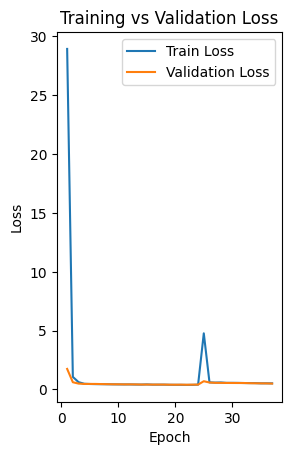

In [62]:
# LOSS CURVES
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

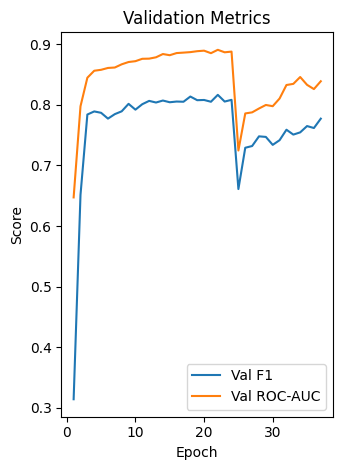

In [63]:

# METRICS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_scores, label="Val F1")
plt.plot(epochs_range, val_roc_scores, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix + ROC

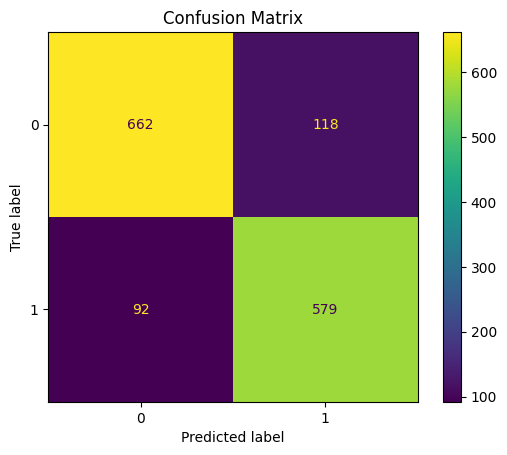

NameError: name 'RocCurveDisplay' is not defined

In [64]:
# VISUALIZATION
cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve")
plt.show()

# Model 2.  Graph Attention Networks(GAT)

In [56]:
# ATTENTION MODEL

class AttentionGNN(nn.Module):
    def __init__(self, node_dim, global_dim):
        super().__init__()

        self.conv1 = GATConv(node_dim, 64, heads=4, concat=True)
        self.conv2 = GATConv(64 * 4, 64)

        self.global_emb = nn.Linear(global_dim, 64)

        self.fc = nn.Sequential(
            nn.Linear(64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, batch, u = data.x, data.edge_index, data.batch, data.u

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        x = global_mean_pool(x, batch)
        u = self.global_emb(u)

        x = torch.cat([x, u], dim=1)

        return self.fc(x)

# GNNExplainer (Interpretability)

In [57]:
# GNN EXPLAINER
explainer = GNNExplainer(model, epochs=200)

data_sample = next(iter(test_loader)).to(device)

node_feat_mask, edge_mask = explainer.explain_graph(
    data_sample.x,
    data_sample.edge_index,
    edge_attr=data_sample.edge_attr
)

print("Node importance:", node_feat_mask)
print("Edge importance:", edge_mask)

TypeError: GNNExplainer.__init__() got multiple values for argument 'epochs'

# Attention Weights (from GAT)

In [ ]:
# SYMBOLIC REGRESSION
# Use global features as input
X = global_samples  # from earlier
y = df['label'].values

model_sr = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt", "log", "exp"],
)

model_sr.fit(X, y)

print(model_sr)

In [ ]:
'''# Extract other features

def extract_pymatgen_features(cif_file):
    structure = Structure.from_file(cifs_path + cif_file)

    # Basic structural properties
    volume = structure.volume
    density = structure.density
    num_atoms = len(structure)

    # Atomic properties
    elements = [site.specie for site in structure]

    for_mean_mass = []

    for el in elements:
        try:
            for_mean_mass.append(el.atomic_mass)
        except:
            for_mean_mass.append(0)

    mean_mass = np.mean(for_mean_mass)
    mean_eneg = np.mean([el.X for el in elements if el.X is not None])

    add_features = [volume, density, num_atoms, mean_mass, mean_eneg]

    return add_features
'''

In [ ]:
'''# Apply feature extraction to all samples
additional_features = []

for cif in df['cif']:
    features = extract_pymatgen_features(cif)
    additional_features.append(features)

additional_features_df = pd.DataFrame(additional_features, columns=[
    'volume', 'density', 'num_atoms', 'mean_mass', 'mean_eneg'
])

# Combine with original dataframe
df = pd.concat([df, additional_features_df], axis=1)'''

In [ ]:
'''node_features_all = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    try:
        structure = Structure.from_file(row['cif_path'])
        node_feat = get_node_features(structure)
        node_features_all.append(node_feat)
    except:
        continue

node_features_all = np.vstack(node_features_all)

node_scaler = StandardScaler()
node_scaler.fit(node_features_all)

print("Node scaler fitted.")'''

100%|██████████| 6767/6767 [42:29<00:00,  2.65it/s]

Node scaler fitted.


In [ ]:
'''class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.15):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-((distances[..., np.newaxis] - self.filter) ** 2) / (self.var ** 2))

gaussian_expansion = GaussianDistance()'''

In [ ]:
'''def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # Node features
    node_feat = get_node_features(structure)
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # Positions
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # Edges
    edge_index = []
    edge_attr = []

    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)

        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append(dist)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global features
    lattice = structure.lattice

    global_feat = [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

    u = torch.tensor(global_feat, dtype=torch.float).unsqueeze(0)

    # Label
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, pos=pos)
    data.u = u

    return data'''

In [ ]:
'''print("Building graphs...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    graph_path = os.path.join(GRAPH_DIR, f"{row['mp_material_id']}.pt")

    if os.path.exists(graph_path):
        continue

    try:
        graph = build_graph(row)
        torch.save(graph, graph_path)
    except Exception as e:
        print(f"Error: {row['mp_material_id']} | {e}")'''

Building graphs...


100%|██████████| 9668/9668 [24:50<00:00,  6.49it/s]


In [ ]:
'''# Wrap saved graph files into a PyTorch Geometric Dataset

from torch_geometric.data import Dataset
import torch
import os

class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        self.graph_dir = graph_dir
        self.files = [f for f in os.listdir(graph_dir) if f.endswith('.pt')]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])
        return torch.load(path, weights_only=False)'''

In [ ]:
'''# Create loaders with batch_size = 32

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset # Import Subset

# Instantiate the dataset
dataset = CrystalDataset(GRAPH_DIR)

# Extract labels for stratification
labels = [data.y.item() for data in dataset]

indices = list(range(len(dataset)))

train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)
val_idx, test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=[labels[i] for i in temp_idx], random_state=42)

# Create Subsets for each split
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)'''

In [ ]:
''''import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define GLOBAL_DIM (inferred from 13 features in build_graph function)
GLOBAL_DIM = 14 # Changed from 13 to 14

# Placeholder for CharlesCGCNN model
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim):
        super(CharlesCGCNN, self).__init__()
        self.node_emb = nn.Linear(node_dim, 64)
        self.edge_emb = nn.Linear(edge_dim, 64)
        self.global_emb = nn.Linear(global_dim, 64)

        self.conv1 = GCNConv(64, 64)
        self.conv2 = GCNConv(64, 64)

        self.fc = nn.Sequential(
            nn.Linear(64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, u, batch = data.x, data.edge_index, data.edge_attr, data.u, data.batch

        x = self.node_emb(x)
        # Note: GCNConv expects scalar edge_weight, not multi-dimensional edge features.
        # The embedded edge_attr below is not directly used by GCNConv in its current form.
        _ = self.edge_emb(edge_attr) # The embedded edge features are computed but not passed to GCNConv
        u = self.global_emb(u)

        # Pass None for edge_weight to GCNConv, as it expects scalar weights.
        x = torch.relu(self.conv1(x, edge_index, None))
        x = torch.relu(self.conv2(x, edge_index, None))

        x_global = global_mean_pool(x, batch)

        combined = torch.cat([x_global, u], dim=1)

        return self.fc(combined)

# Binary classification setup

model = CharlesCGCNN(node_dim=8, edge_dim=42, global_dim=GLOBAL_DIM).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)
''''

In [ ]:
'''# Training loop with validation monitoring

def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y.float().unsqueeze(1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = criterion(out, data.y.float().unsqueeze(1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    return total_loss / len(loader), torch.cat(preds), torch.cat(labels)


best_val_loss = float('inf')
patience = 15
counter = 0

for epoch in range(1, 101):
    train_loss = train_epoch(train_loader)
    val_loss, _, _ = eval_epoch(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break'''

Epoch 001 | Train Loss: 1.0303 | Val Loss: 0.6481
Epoch 002 | Train Loss: 0.7514 | Val Loss: 0.4888
Epoch 003 | Train Loss: 0.5543 | Val Loss: 0.4763
Epoch 004 | Train Loss: 0.5548 | Val Loss: 0.4893
Epoch 005 | Train Loss: 0.5254 | Val Loss: 0.4811
Epoch 006 | Train Loss: 0.5318 | Val Loss: 0.4664
Epoch 007 | Train Loss: 0.5209 | Val Loss: 0.4906
Epoch 008 | Train Loss: 0.4857 | Val Loss: 0.4567
Epoch 009 | Train Loss: 0.4863 | Val Loss: 0.4578
Epoch 010 | Train Loss: 0.4709 | Val Loss: 0.4728
Epoch 011 | Train Loss: 0.4705 | Val Loss: 0.4629
Epoch 012 | Train Loss: 0.4721 | Val Loss: 0.5991
Epoch 013 | Train Loss: 0.4793 | Val Loss: 0.4543
Epoch 014 | Train Loss: 0.4508 | Val Loss: 0.5040
Epoch 015 | Train Loss: 0.4485 | Val Loss: 0.4447
Epoch 016 | Train Loss: 0.4564 | Val Loss: 0.4569
Epoch 017 | Train Loss: 0.4556 | Val Loss: 0.4480
Epoch 018 | Train Loss: 0.4446 | Val Loss: 0.4580
Epoch 019 | Train Loss: 0.4497 | Val Loss: 0.4794
Epoch 020 | Train Loss: 0.4400 | Val Loss: 0.4388


In [ ]:
'''from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def evaluate_model(loader, name):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy()
    labels = torch.cat(labels_list).numpy()
    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary'''

In [ ]:
'''import matplotlib.pyplot as plt

# Load the best model weights
model.load_state_dict(torch.load('best_model.pt'))

# Evaluate on the test set to get labels, probs, and binary for plotting
labels, probs, binary = evaluate_model(test_loader, "Test")'''


Test Performance:
Accuracy : 0.8484
F1-score : 0.8382
ROC-AUC  : 0.9206
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       780
         1.0       0.83      0.85      0.84       671

    accuracy                           0.85      1451
   macro avg       0.85      0.85      0.85      1451
weighted avg       0.85      0.85      0.85      1451



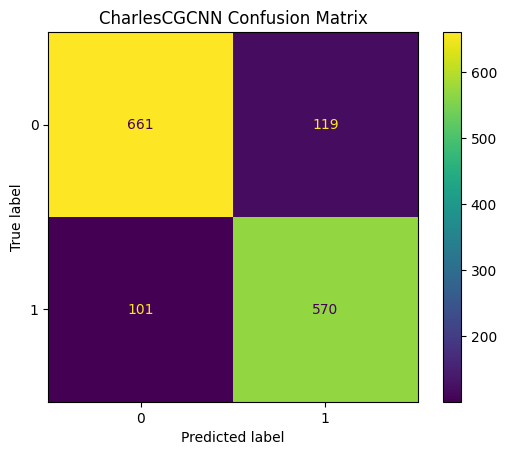

In [ ]:
''from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("CharlesCGCNN Confusion Matrix")
plt.show()''

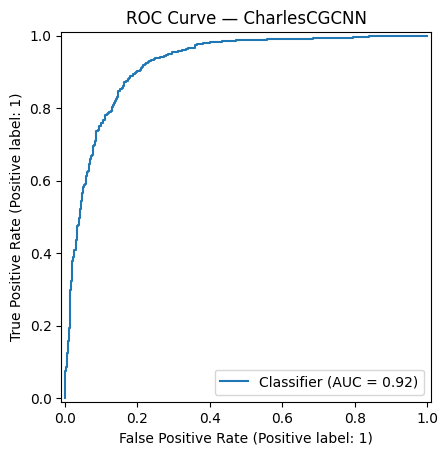

In [ ]:
'''from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve — CharlesCGCNN")
plt.show()'''

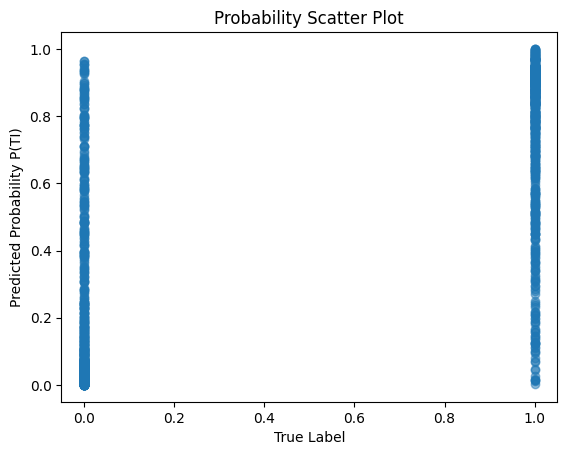

In [ ]:
'''plt.scatter(labels, probs, alpha=0.5)
plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title("Probability Scatter Plot")
plt.show()'''

In [ ]:
'''# Gradient-based importance

# Take a single graph from the test_loader
sample_graph = next(iter(test_loader))
data = sample_graph.to(device)
data.x.requires_grad = True

output = model(data)
output.sum().backward()

saliency = data.x.grad.abs().sum(dim=1)'''